In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from vizman import viz

base_dir = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")
csv_files = {
    'humans': base_dir / "hcp_schaefer_100_dataset/05_mst_animal_0_compared_with_hcp_schaefer_100/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_hcp_schaefer_100.csv",
    'diffusion': base_dir / "kaysons_generated_networks_diffusion/05_mst_animal_0_compared_with_diffusion/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_diffusion.csv",
    'propagation': base_dir / "kaysons_generated_networks_propagation/05_mst_animal_0_compared_with_propagation/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_propagation.csv",
    'routing': base_dir / "kaysons_generated_networks_routing/05_mst_animal_0_compared_with_routing/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_routing.csv",
    'mami': base_dir / "suarez_MaMI_dataset/05_mst_animal_0_compared_with_mami/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_mami.csv"
}


Processing humans...
  Found 103 minima
Processing diffusion...
  Found 100 minima
Processing propagation...
  Found 100 minima
Processing routing...
  Found 100 minima
Processing mami...
  Found 225 minima


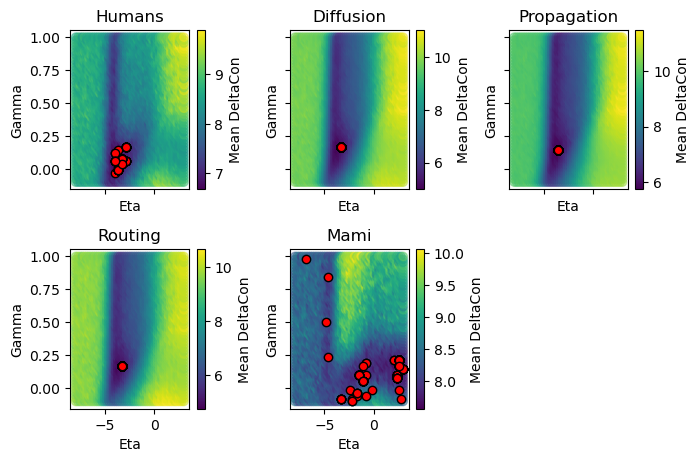

In [30]:

# Store all minima for each network type
all_minima = {}

# Do this in subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=viz.cm_to_inch((18,12)), sharex=True, sharey=True, dpi=100)
axs = axs.flatten()

# Process each CSV file
for i, (network_name, csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    
    # Load the data
    df = pd.read_csv(csv_path)
    
    # Drop filename column if it exists
    if 'filename' in df.columns:
        df.drop(columns=["filename"], inplace=True)
    
    # Group by eta and gamma and calculate mean
    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()
    
    # Find minima for each subject (DeltaCon columns)
    delta_con_columns = [col for col in df_mean.columns if "DeltaCon_subject_" in col]
    
    df_mean["DeltaCon_mean"] = df_mean[delta_con_columns].mean(axis=1)
    
    minima_eta = []
    minima_gamma = []
    
    for col in delta_con_columns:
        # Find the row with minimum DeltaCon for this subject
        min_idx = df_mean[col].idxmin()
        minima_eta.append(df_mean.loc[min_idx, "eta"])
        minima_gamma.append(df_mean.loc[min_idx, "gamma"])
    
    all_minima[network_name] = {
        'eta': minima_eta,
        'gamma': minima_gamma,
        'df_mean': df_mean
    }
    print(f"  Found {len(minima_eta)} minima")
    axs[i].scatter(df_mean["eta"], df_mean["gamma"], c=df_mean["DeltaCon_mean"], label=network_name, alpha=0.5)
    axs[i].set_title(network_name.capitalize())
    axs[i].set_xlabel("Eta")
    axs[i].set_ylabel("Gamma")
    
    # Add minima points
    axs[i].scatter(minima_eta, minima_gamma, color='red', label='Minima', edgecolor='black')
    # axs[i].legend()
    # Add colorbar
    norm = plt.Normalize(df_mean["DeltaCon_mean"].min(), df_mean["DeltaCon_mean"].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axs[i], label="Mean DeltaCon")
    
# Remove empty subplot
if len(csv_files) < len(axs):
    for j in range(len(csv_files), len(axs)):
        fig.delaxes(axs[j])

plt.tight_layout()

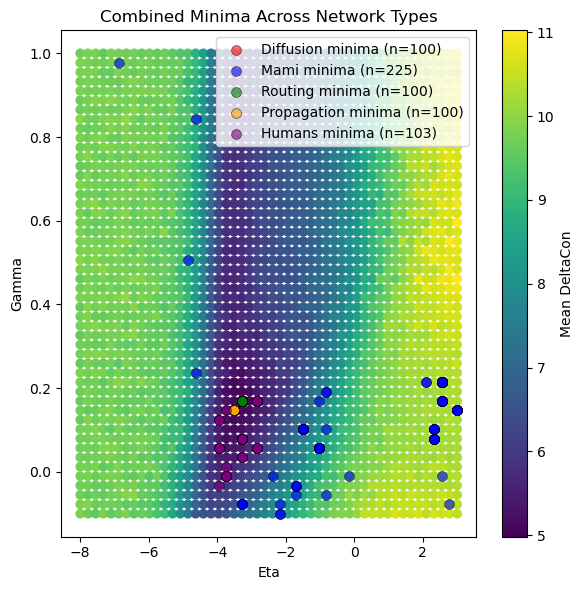


SUMMARY STATISTICS

DIFFUSION:
  Eta range: [-3.286, -3.286]
  Gamma range: [0.169, 0.169]
  Eta mean ± std: -3.286 ± 0.000
  Gamma mean ± std: 0.169 ± 0.000

MAMI:
  Eta range: [-6.878, 3.000]
  Gamma range: [-0.100, 0.978]
  Eta mean ± std: 1.135 ± 2.095
  Gamma mean ± std: 0.147 ± 0.113

ROUTING:
  Eta range: [-3.286, -3.286]
  Gamma range: [0.169, 0.169]
  Eta mean ± std: -3.286 ± 0.000
  Gamma mean ± std: 0.169 ± 0.000

PROPAGATION:
  Eta range: [-3.510, -3.510]
  Gamma range: [0.147, 0.147]
  Eta mean ± std: -3.510 ± 0.000
  Gamma mean ± std: 0.147 ± 0.000

HUMANS:
  Eta range: [-3.959, -2.837]
  Gamma range: [-0.033, 0.169]
  Eta mean ± std: -3.321 ± 0.351
  Gamma mean ± std: 0.078 ± 0.054


In [17]:

# Create the combined plot
plt.figure(figsize=(6,6), dpi=100)

# Define colors for each network type
colors = {
    'diffusion': 'red',
    'mami': 'blue',
    'routing': 'green', 
    'propagation': 'orange',
    'humans': 'purple'
}

# Plot the landscape from one network (they should be similar)
# Using diffusion as the base
base_network = 'diffusion'
df_mean = all_minima[base_network]['df_mean']
if 'DeltaCon_mean' not in df_mean.columns:
    # Calculate mean across all subjects
    delta_con_columns = [col for col in df_mean.columns if "DeltaCon_subject_" in col]
    df_mean['DeltaCon_mean'] = df_mean[delta_con_columns].mean(axis=1)

plt.scatter(df_mean["eta"], df_mean["gamma"], c=df_mean["DeltaCon_mean"], 
            cmap='viridis') # , # alpha=0.3, s=30, label='Landscape (mean DeltaCon)')

# Add colorbar for the landscape
plt.colorbar(label='Mean DeltaCon')

# Plot minima for each network type
for network_name, color in colors.items():
    minima = all_minima[network_name]
    plt.scatter(minima['eta'], minima['gamma'], 
                c=color, marker='o', s=50, alpha=0.6, 
                label=f'{network_name.capitalize()} minima (n={len(minima["eta"])})',
                edgecolors='black', linewidths=0.5)

plt.xlabel('Eta')
plt.ylabel('Gamma') 
plt.title('Combined Minima Across Network Types') 
plt.legend(loc='best')
plt.tight_layout()

# Save the figure
output_path = "/home/claude/combined_minima_plot.png"
# plt.savefig(output_path, dpi=150, bbox_inches='tight')
# print(f"\nPlot saved to: {output_path}")
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
for network_name in colors.keys():
    minima = all_minima[network_name]
    print(f"\n{network_name.upper()}:")
    print(f"  Eta range: [{np.min(minima['eta']):.3f}, {np.max(minima['eta']):.3f}]")
    print(f"  Gamma range: [{np.min(minima['gamma']):.3f}, {np.max(minima['gamma']):.3f}]")
    print(f"  Eta mean ± std: {np.mean(minima['eta']):.3f} ± {np.std(minima['eta']):.3f}")
    print(f"  Gamma mean ± std: {np.mean(minima['gamma']):.3f} ± {np.std(minima['gamma']):.3f}")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_58485/612323017.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,


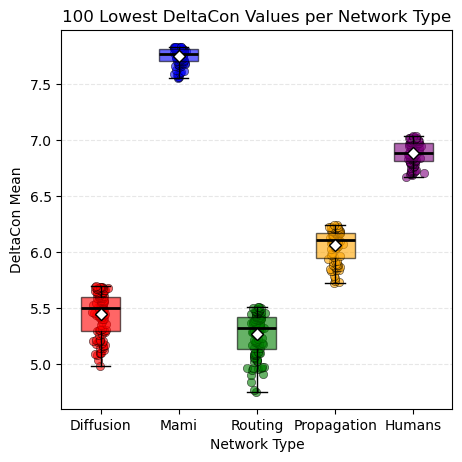


SUMMARY STATISTICS (100 LOWEST VALUES)

DIFFUSION:
  Min: 4.981106
  Q1 (25th percentile): 5.289172
  Median: 5.499660
  Q3 (75th percentile): 5.600928
  Max: 5.696073
  Mean ± std: 5.441207 ± 0.193730

MAMI:
  Min: 7.559736
  Q1 (25th percentile): 7.708207
  Median: 7.768703
  Q3 (75th percentile): 7.810609
  Max: 7.831691
  Mean ± std: 7.750956 ± 0.071672

ROUTING:
  Min: 4.752693
  Q1 (25th percentile): 5.130257
  Median: 5.318127
  Q3 (75th percentile): 5.418491
  Max: 5.509441
  Mean ± std: 5.264733 ± 0.187909

PROPAGATION:
  Min: 5.723391
  Q1 (25th percentile): 5.949541
  Median: 6.107846
  Q3 (75th percentile): 6.172643
  Max: 6.241542
  Mean ± std: 6.063378 ± 0.139625

HUMANS:
  Min: 6.667823
  Q1 (25th percentile): 6.812579
  Median: 6.885225
  Q3 (75th percentile): 6.970563
  Max: 7.041075
  Mean ± std: 6.883916 ± 0.096634


In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Collect the 100 lowest DeltaCon values for each network type
boxplot_data = []
labels = []

colors_list = ['red', 'blue', 'green', 'orange', 'purple']
network_types = ['diffusion', 'mami', 'routing', 'propagation', 'humans']

for network_name in network_types:
    df_mean = all_minima[network_name]['df_mean']
    
    # Ensure DeltaCon_mean exists
    if 'DeltaCon_mean' not in df_mean.columns:
        delta_con_columns = [col for col in df_mean.columns if "DeltaCon_subject_" in col]
        df_mean['DeltaCon_mean'] = df_mean[delta_con_columns].mean(axis=1)
    
    # Get the 100 lowest values from the ENTIRE dataframe
    lowest_100 = df_mean['DeltaCon_mean'].nsmallest(100).values
    boxplot_data.append(lowest_100)
    labels.append(network_name.capitalize())

# Create the boxplot
fig, ax = plt.subplots(figsize=viz.cm_to_inch((12,12)), dpi=100)

bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,
                showmeans=True, meanline=False,
                medianprops=dict(color='black', linewidth=2),
                meanprops=dict(marker='D', markerfacecolor='white', 
                              markeredgecolor='black', markersize=6))

# Add scatter points for the 100 lowest values
for i, data in enumerate(boxplot_data):
    x = np.random.normal(i + 1, 0.04, size=len(data))  # Jitter the x-values
    ax.scatter(x, data, color=colors_list[i], alpha=0.6, edgecolor='black', linewidth=0.5)

# Color the boxes
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('DeltaCon Mean')
ax.set_xlabel('Network Type')
ax.set_title('100 Lowest DeltaCon Values per Network Type')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary statistics for the 100 lowest values
print("\n" + "="*60)
print("SUMMARY STATISTICS (100 LOWEST VALUES)")
print("="*60)
for i, network_name in enumerate(network_types):
    data = boxplot_data[i]
    print(f"\n{network_name.upper()}:")
    print(f"  Min: {np.min(data):.6f}")
    print(f"  Q1 (25th percentile): {np.percentile(data, 25):.6f}")
    print(f"  Median: {np.median(data):.6f}")
    print(f"  Q3 (75th percentile): {np.percentile(data, 75):.6f}")
    print(f"  Max: {np.max(data):.6f}")
    print(f"  Mean ± std: {np.mean(data):.6f} ± {np.std(data):.6f}")